In [1]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
df = pd.read_parquet("data/interim/02_cleaned.parquet")

X = df["message"]
y = (df["label"] == "spam").astype(int)  # spam = 1, ham = 0

# Sanity check: messages must be strings, not token arrays
assert isinstance(X.iloc[0], str), "Messages are not joined strings"
print(f"{len(df)} messages, {y.mean():.1%} spam")

5169 messages, 12.6% spam


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # keep the same spam ratio in both sets
    random_state=42,   # reproducible split
)

In [4]:
pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB()),
])

param_grid = {
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__min_df": [1, 2],
    "vectorizer__max_df": [0.9, 1.0],
    "classifier__alpha": [0.01, 0.1, 0.25, 0.5, 1.0],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated F1: {grid_search.best_score_:.4f}")

Best parameters: {'classifier__alpha': 0.25, 'vectorizer__max_df': 0.9, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2)}
Best cross-validated F1: 0.9288


              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.91      0.89      0.90       131

    accuracy                           0.98      1034
   macro avg       0.95      0.94      0.94      1034
weighted avg       0.98      0.98      0.98      1034



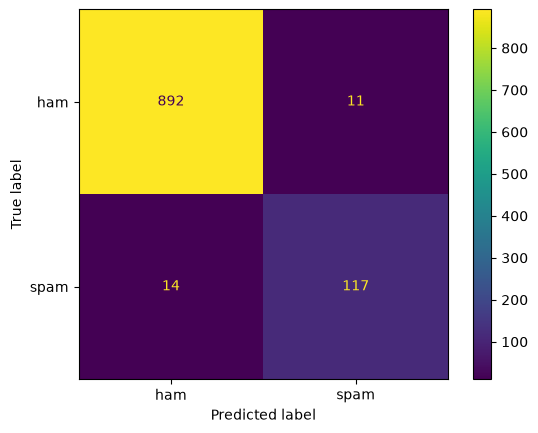

In [5]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["ham", "spam"]);

In [6]:
model_filename = "models/spam_detection_model.joblib"
joblib.dump(best_model, model_filename)
print(f"Model saved to {model_filename}")

Model saved to models/spam_detection_model.joblib
